In [13]:
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

# test the connection
with engine.connect() as connection:
    result = connection.execute(text("SELECT current_database(), current_user;"))
    print(result.fetchone())


('fca', 'mbildstein')


## Data Analysis

In [14]:
import pandas as pd

buildings = pd.read_sql("SELECT * FROM buildings WHERE is_active", engine)
deferred_maintenance = pd.read_sql("SELECT * FROM deferred_maintenance WHERE is_active", engine)
cost_model_rates = pd.read_sql("SELECT * FROM cost_model_rates", engine)
component_ratings = pd.read_sql("SELECT * FROM component_ratings", engine)
components = pd.read_sql("SELECT * FROM components", engine)
component_groups = pd.read_sql("SELECT * FROM component_groups", engine)

print(f"Buildings: {len(buildings)}")
print(f"DM items: {len(deferred_maintenance)}")
print(f"Component ratings: {len(component_ratings)}")


Buildings: 9
DM items: 129
Component ratings: 363


### FCI per Building

FCI (Facility Condition Index) = DM / CRV

- **DM** (Deferred Maintenance): sum of estimated costs for all active deficiency items
- **CRV** (Current Replacement Value): building area × sum of all component cost rates for the assigned cost model

Thresholds: Good < 5% | Fair 5–10% | Poor > 10%

In [15]:
# CRV: sum all component rates per cost model, then multiply by building area
crv_by_cost_model = (
    cost_model_rates
    .groupby("cost_model_id")["cost_per_sqft"]
    .sum()
    .reset_index(name="rate_per_sqft")
)

buildings_crv = buildings.merge(crv_by_cost_model, on="cost_model_id")
buildings_crv["crv"] = buildings_crv["area_sqft"] * buildings_crv["rate_per_sqft"]

# DM: sum estimated cost per building
dm_per_building = (
    deferred_maintenance
    .groupby("building_id")["estimated_cost"]
    .sum()
    .reset_index(name="total_dm")
)

# FCI per building
fci_df = (
    buildings_crv[["id", "name", "area_sqft", "year_built", "crv"]]
    .merge(dm_per_building, left_on="id", right_on="building_id", how="left")
    .drop(columns="building_id")
    .fillna({"total_dm": 0})
)
fci_df["fci"] = fci_df["total_dm"] / fci_df["crv"]
fci_df["condition"] = pd.cut(
    fci_df["fci"],
    bins=[-1, 0.05, 0.10, float("inf")],
    labels=["Good", "Fair", "Poor"],
)
fci_df = fci_df.sort_values("fci", ascending=False).reset_index(drop=True)

display(
    fci_df[["name", "area_sqft", "year_built", "crv", "total_dm", "fci", "condition"]]
    .style
    .format({"crv": "${:,.0f}", "total_dm": "${:,.0f}", "fci": "{:.1%}"})
    .background_gradient(subset="fci", cmap="RdYlGn_r")
)


,name,area_sqft,year_built,crv,total_dm,fci,condition
0,Western State Apparatus Building,17000,1955,"$5,444,760","$3,977,655",73.1%,Poor
1,Garage,1777,1980,"$717,677","$394,130",54.9%,Poor
2,Grand Plaza (aka Grande Foods),55712,1981,"$19,147,657","$7,746,751",40.5%,Poor
3,Civic Center (aka Council Chamber),5475,1981,"$2,856,964","$553,372",19.4%,Poor
4,Fleet Maintenance Building (aka Mechanic Shop),4396,2000,"$1,775,413","$313,567",17.7%,Poor
5,Cornelius Library (within the Cornelius Place structure),16353,2017,"$8,123,843","$1,297,230",16.0%,Poor
6,Administration Building (aka Public Works Building),7480,2000,"$3,020,948","$278,550",9.2%,Fair
7,Public Safety Building,17885,1995,"$8,501,814","$671,155",7.9%,Fair
8,Community Center,13518,1966,"$7,566,714","$496,003",6.6%,Fair


### Probabilistic Capital Renewal Model (Monte Carlo)

For each assessed component with a non-zero replacement rate:
- **Renewal year** = current year + `remaining_useful_life × Uniform(0.80, 1.20)` — i.e., ±20%
- **Base cost** = building area × component cost rate (from cost model)
- **Simulated cost** = base cost × Uniform(0.80, 1.20) — i.e., ±20%

Components with `remaining_useful_life ≤ HORIZON / 0.8` are included so that fast-maturing components (YTO scaled down 20%) are captured within the window.

1,000 simulations over a 20-year horizon. Output: P10 / P50 / P90 annual renewal cost curves.

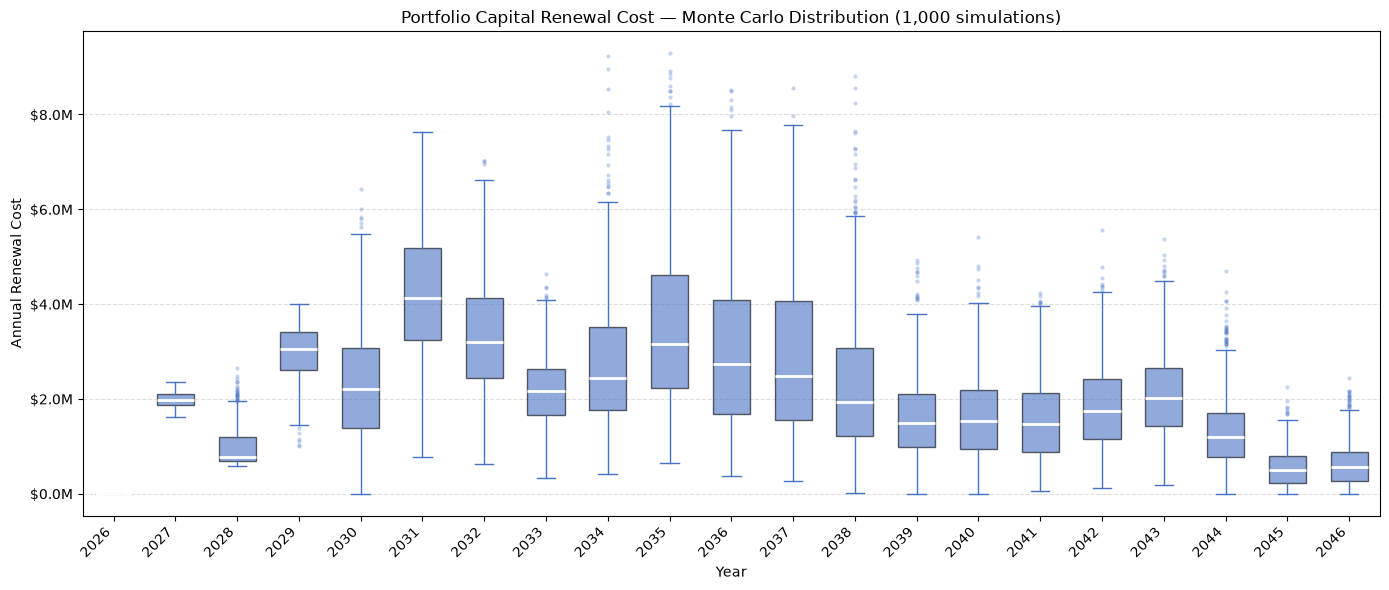

Total P50 renewal cost over 20 years: $40,760,352


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

N_SIMULATIONS = 1_000
CURRENT_YEAR = 2026
HORIZON = 20

# Build component-level renewal table
renewal = (
    component_ratings
    .merge(
        buildings[["id", "name", "area_sqft", "cost_model_id"]],
        left_on="building_id", right_on="id",
        suffixes=("", "_bldg"),
    )
    .merge(
        cost_model_rates[["cost_model_id", "component_id", "cost_per_sqft"]],
        on=["cost_model_id", "component_id"],
    )
)

renewal = renewal[
    (renewal["cost_per_sqft"] > 0) & (renewal["remaining_useful_life"] > 0)
].copy()

renewal["base_cost"] = renewal["area_sqft"] * renewal["cost_per_sqft"]

# Include components that could land inside the horizon when YTO is scaled down 20%
renewal = renewal[renewal["remaining_useful_life"] <= HORIZON / 0.8].reset_index(drop=True)

years = list(range(CURRENT_YEAR, CURRENT_YEAR + HORIZON + 1))
rng = np.random.default_rng(42)
base_costs = renewal["base_cost"].to_numpy()
base_yto = renewal["remaining_useful_life"].to_numpy()
building_ids = renewal["building_id"].to_numpy()

def run_simulations(costs, yto, n_sims):
    matrix = np.zeros((n_sims, len(years)))
    for i in range(n_sims):
        sim_costs = costs * rng.uniform(0.8, 1.2, size=len(costs))
        sim_years = np.round(CURRENT_YEAR + yto * rng.uniform(0.8, 1.2, size=len(yto))).astype(int)
        in_range = (sim_years >= CURRENT_YEAR) & (sim_years <= CURRENT_YEAR + HORIZON)
        np.add.at(matrix[i], sim_years[in_range] - CURRENT_YEAR, sim_costs[in_range])
    return matrix

# --- Portfolio-level Monte Carlo ---
sim_matrix = run_simulations(base_costs, base_yto, N_SIMULATIONS)

mc_portfolio = pd.DataFrame({
    "year": years,
    "p10": np.percentile(sim_matrix, 10, axis=0),
    "p50": np.percentile(sim_matrix, 50, axis=0),
    "p90": np.percentile(sim_matrix, 90, axis=0),
})

# --- Per-building P50 point estimate ---
unique_buildings = renewal[["building_id", "name"]].drop_duplicates()
building_year_p50 = []

for _, row in unique_buildings.iterrows():
    bid = row["building_id"]
    mask = building_ids == bid
    sim_b = run_simulations(base_costs[mask], base_yto[mask], N_SIMULATIONS)
    p50 = np.percentile(sim_b, 50, axis=0)
    for j, yr in enumerate(years):
        building_year_p50.append({"building_id": bid, "building": row["name"], "year": yr, "p50_cost": p50[j]})

mc_by_building = pd.DataFrame(building_year_p50)

# --- Box-and-whisker chart ---
# sim_matrix shape: (N_SIMULATIONS, len(years)) — boxplot treats each column as one box
fig, ax = plt.subplots(figsize=(14, 6))

ax.boxplot(
    sim_matrix,
    positions=years,
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor="#4472C4", alpha=0.6),
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color="#4472C4"),
    capprops=dict(color="#4472C4"),
    flierprops=dict(marker="o", markersize=3, alpha=0.3, markerfacecolor="#4472C4", markeredgewidth=0),
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.set_xlabel("Year")
ax.set_ylabel("Annual Renewal Cost")
ax.set_title("Portfolio Capital Renewal Cost — Monte Carlo Distribution (1,000 simulations)")
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Total P50 renewal cost over {HORIZON} years: ${mc_portfolio['p50'].sum():,.0f}")
